# Initialization, Imports

In [1]:
import pandas as pd

import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

/home/wjh/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_events = pd.read_pickle("./data/CAC_matched.pkl")
df_names = pd.read_parquet("./data/authority_file_cac_alma.parquet")
df_names_cac = df_names.dropna(subset="cac_id")
cac_id_dict = dict(zip(df_names_cac.cac_id.to_list(), df_names_cac.final_id))

df_events["date_start"] = df_events["date_start"].apply(lambda x:x.date())
df_events["date_end"] = df_events["date_end"].apply(lambda x:x.date())

In [3]:
df_events

,person_id,event_place,event_place_parent,event_place_id,event_place_parent_id,date_start,date_end,event_metadata
0,2033185,Kolegium Większe {Uniwersytetu Krakowskiego},Uniwersytet Krakowski (Akademia Krakowska),7613.0,8309.0,1517-04-23,1534-11-27,"{'position': 'kolegiat', 'event_type': 'trwani..."
1,2009152,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1629-04-23,1629-10-15,"{'position': 'dziekan (wydziału)', 'event_type..."
2,2001785,województwo bełskie,województwo bełskie,8372.0,8372.0,1640-10-16,1641-04-22,"{'position': 'wojewodzic', 'event_type': 'trwa..."
4,1995358,Kolegium Większe {Uniwersytetu Krakowskiego},Uniwersytet Krakowski (Akademia Krakowska),7613.0,8309.0,1444-08-07,1444-08-07,"{'position': 'kolegiat', 'event_type': 'trwani..."
5,1994447,Kolegium Większe {Uniwersytetu Krakowskiego},Uniwersytet Krakowski (Akademia Krakowska),7613.0,8309.0,1432-04-23,1432-04-23,"{'position': 'prepozyt (kolegium)', 'event_typ..."
...,...,...,...,...,...,...,...,...
5144,2031231,Uniwersytet Krakowski (Akademia Krakowska),Uniwersytet Krakowski (Akademia Krakowska),8309.0,8309.0,1522-02-01,1522-02-28,"{'degree_type': 'student', 'event_type': 'trwa..."
5145,2032051,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1756-10-16,1757-04-22,"{'degree_type': 'bakałarz', 'event_type': 'pos..."
5146,2032538,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1778-04-03,1778-04-03,"{'degree_type': 'magister', 'event_type': 'pos..."
5147,2032538,wydział filozofii/sztuk wyzwolonych {Uniwersyt...,Uniwersytet Krakowski (Akademia Krakowska),8429.0,8309.0,1779-03-19,1779-03-19,"{'degree_type': 'magister', 'event_type': 'pos..."


In [4]:
df_names

,final_id,alma_born,alma_died,first_polish_pub,cac_id,alma_name
0,0,NaN,NaN,None,NaN,A. M.
1,1,1604.0,1691.0,None,NaN,"Abelly, Louis (1604-1691)"
2,2,1606.0,1664.0,None,NaN,"Ablancourt, Nicolas Perrot d' (1606-1664)"
3,3,1600.0,1700.0,None,2014948.0,"Abrek, Andrzej (16..-1700)"
4,4,NaN,1656.0,None,2014945.0,"Abrek, Andrzej (?-1656)"
...,...,...,...,...,...,...
3975,3697,1600.0,1799.0,None,2003875.0,"Celejowicz, Maciej Paweł (16..-17..)"
3976,3698,1544.0,1617.0,None,NaN,"Botero, Giovanni (1540-1617)"
3977,3698,1544.0,1617.0,None,NaN,"Botero, Giovanni (1544-1617)"
3978,3699,NaN,NaN,None,NaN,Aristoteles (384-322 a.C.)


In [5]:
publications_df = pd.read_pickle("./data/ALMA_matched.pkl")
publications_df = publications_df[publications_df["all_names_final_id"].apply(lambda x: len(x) > 1)]

In [6]:
publications_df

,ALMA_id,autors_list,title,subtitle,publication_city,date_start,date_end,record_type,all_names,all_names_final_id,contributing_persons,contributing_organizations,genre,subjects_people,subjects_topics,subjects_places
208,991000470979705067,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",na rok ... [...] /,[a: Polska | d: Kraków.],1806-01-01,1832-12-31,Tekst,"[Koch, Rudolf Bogumił (1771-post 1854), Ryszko...","(1362, 1283, 2604)","[(Ryszkowski, Franciszek Ksawery (1746-1809), ...",[(Drukarnia Antoniego Gröbla Wdowy i Sukcesoró...,"[Kalendarze, Kalendarze]",None,None,None
217,991000474089705067,"[Sienkiewicz, Piotr (czynny 1685-1701)]","Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...","Dum A [...] Joanne De Małachowice Małachowski,...",[a: Polska | d: Kraków.],1688-03-18,1690-03-18,Tekst,"[Schedel, Mikołaj Aleksander (1644-1708), Sien...","(2667, 2996, 2734)","[(Schedel, Mikołaj Aleksander (1644-1708), [Dr...",None,None,None,None,None
226,991000475869705067,"[Woysznarowicz, Kazimierz Jan ( -1680)]",Orator Politiczny Weselnym y Pogrzebowym Słvzą...,None,[a: Polska | d: Kraków.],1646-01-01,1648-12-31,Tekst,"[Woysznarowicz, Kazimierz Jan ( -1680), Cezary...","(2633, 3361, 3641)","[(Sapieha, Jan Ferdynand (1629-1659), [Adr. de...",None,"[Mowy weselne, Przemówienia polskie, Mowy pogr...",None,None,None
281,991000493069705067,"[Skarszewski, Wojciech (1742-1827)]",Skutki Nowey Filozofii Spokoyności Kraiowey gr...,None,[a: Polska | d: Warszawa.],1791-01-01,1793-12-31,Tekst,"[Skarszewski, Wojciech (1742-1827), Gröll, Mic...","(990, 2767)","[(Gröll, Michał (1722-1798), [Księg.])]",None,None,None,None,None
296,991000497659705067,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767)]",Auspicia Sandomiriensis Palatinæ Curulis Secun...,None,[a: Polska | d: Kraków.],1750-08-22,1752-08-22,Tekst,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767),...","(170, 3267)","[(Wielopolski, Jan (?-1773), [Adr. ded.])]","[(Drukarnia Akademicka (Kraków), None)]",None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788191,991008986109705067,"[Trigault, Nicolas (1577-1628)]","Nowiny Abo Dzieie dwuletnie Chinenskie, /",None,[a: Polska | d: Kraków.],1614-01-01,1616-12-31,None,"[Januszowski, Jan (1550-1613), Jędrzejowczyk, ...","(3681, 2407, 3378, 3126, 1207)","[(Jędrzejowczyk, Maciej (15..-1638), None), (J...",None,None,None,None,None
788199,991008989789705067,"[Warzyński, Andrzej Paweł (16..-16..)]",Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,None,[a: Polska | d: Kraków.],1680-07-20,1682-07-20,None,"[Cezary, Franciszek (ok. 1660-1724), Warzyński...","(368, 273, 3226)","[(Bryszkiewicz, Jacek (16..-1689), [Adr. ded.]...",None,None,None,None,None
790406,991011913959705067,"[Jurkowski, Jan (1580-1635)]","""Tragedya o polskim Scylurusie""",None,None,1889-01-01,1889-12-31,Tekst,"[Jurkowski, Jan (1580-1635), Pauli, Żegota (18...","(2212, 1260)","[(Pauli, Żegota (1814-1895), [Kopista])]",None,None,None,None,None
790498,991011937969705067,"[Władysławski, Gabriel (ca 1570-1631)]","""Intentio erectionis certarum lecturarum in Ac...",None,None,1672-01-01,1672-12-31,Tekst,"[Muczkowski, Józef (1860-1943), Brożek, Jan (1...","(1954, 3406, 263)","[(Muczkowski, Józef (1860-1943), [Właściciel])...",None,None,None,None,None


Provided topics are sparse and chaotic and often unique and with varying granularity

In [7]:
print(set(x for lst in publications_df["subjects_topics"].dropna() for x in lst))

{'Oksza (herb)', 'Język grecki', 'Włosi', 'Jednostki miar', 'Kultura', 'Patroni Polski', 'Rzeki', 'Dekalog', 'Regulacja wód płynących', 'Konsekracja', 'Kmita, Piotr (ca.1477-1553)', 'Kaligrafia', 'Prawo zobowiązań', 'Fizjokratyzm', 'Książki', 'Ogrodnictwo', 'Chocim, Bitwa (1621)', 'Przeistoczenie', 'Sprzedaż', 'Filozofia starożytna', 'Ingres', 'Elekcja Augusta II Mocnego (1697)', 'Bazylika Nawiedzenia NMP (Tuchów)', 'Herezje chrześcijańskie', 'Bunty i powstania chłopskie', 'Rzeźba terenu', 'Wychowanie', 'Tętno', 'Ikonolatria', 'Kiła', 'Miłość', 'Pokój', 'Grób Jezusa Chrystusa (Jerozolima)', 'Kazania', 'Eschatologia', 'Liturgia', 'Sztuka pisania', 'Kara Boża', 'Rozwój duchowy', 'Plony', 'Poradnik duchowy', 'Dedukcja', 'Charakter narodowy włoski.', 'Byt (filozofia)', 'Dziesięcina', 'Sakrament spowiedzi', 'Junosza (herb)', 'Bitwa pod Grunwaldem (1410)', 'Język francuski', 'Zakony', 'Charakter narodowy polski.', 'Urzędy ziemskie', 'Grzech', 'Mechanika stosowana', 'Orzeł Biały (herb)', 'Geo

# Make a replacement column for subjects or topics, using title column, embedding and clustering

First prepare strings to embed, and embedding

In [8]:
publications_df["topic_text"] = (
    publications_df[["title", "subtitle"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Embedding

In [ ]:
model = SentenceTransformer("sentence-transformers/distiluse-base-multilingual-cased-v1")

embeddings = model.encode(
    publications_df["topic_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches: 100%|██████████| 189/189 [03:01<00:00,  1.04it/s]


Dimensionality reduction

In [ ]:
pca = PCA(
    n_components=0.97, # keep 97% variance
    random_state=42
)

embeddings_pca = pca.fit_transform(embeddings)

print(
    f"{embeddings.shape[1]} -> "
    f"{embeddings_pca.shape[1]} dimensions"
)

512 -> 282 dimensions


Clustering

In [ ]:
bic_scores = []
models = []

for k in range(3, 20):
    print(k)
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=42,
        max_iter=200,
        n_init=2,
    ).fit(embeddings_pca)
    bic_current = gmm.bic(embeddings_pca)
    bic_scores.append(bic_current)
    print(bic_current)
    models.append(gmm)

best_k = np.argmin(bic_scores) + 3
best_gmm = models[np.argmin(bic_scores)]

publications_df["topic_cluster"] = best_gmm.predict(embeddings_pca)
probs = best_gmm.predict_proba(embeddings_pca)
publications_df["cluster_confidence"] = probs.max(axis=1)
publications_df["cluster_probs"] = list(probs)
print(f"Best k={best_k}")

3
-6579284.94813722
4
-6583036.803631996
5
-6585186.024117005
6
-6586256.74643307
7
-6585053.260375111
8
-6586721.100611097
9
-6585482.966970131
10
-6585206.119461976
11
-6583917.857403041
12
-6612557.735236683
13
-6611960.2132900525
14
-6588208.52252018
15
-6587545.391320619
16
-6604640.252186488
17
-6603323.977188099
18
-6570828.563395766
19
-6599001.804632728
Best k=12


## Checks of quality of topic assignments and embeddings

Components are well separated, only tail is more ambiguous

In [ ]:
log_probs = best_gmm._estimate_weighted_log_prob(embeddings_pca)

top2 = np.sort(log_probs, axis=1)[:, -2:]

gap = top2[:, 1] - top2[:, 0]

print(np.percentile(gap, [5, 25, 50, 75, 95]))

# most samples have a positive gap (with median near 7.33), so for many points the top component is substantially more likely than the second-best

[ 1.5732605   4.39047241  7.33312988 11.78912354 25.04745483]


In [ ]:
entropy = -(probs * np.log(probs + 1e-12)).sum(axis=1)

print(entropy, np.log(best_k)) # Smaller values are more certain, mostly values are small, they are smaller than ln(K) which means they are reasonable

2.4849066497880004 [4.0173594e-02 6.4469719e-01 2.5789944e-02 ... 2.8240045e-17 2.9680697e-07
 6.2703353e-01]


Check hard and soft component sizes

In [ ]:
labels = best_gmm.predict(embeddings_pca)
probs = best_gmm.predict_proba(embeddings_pca)

summary = pd.DataFrame({
    "component": range(best_gmm.n_components),
    "weight": best_gmm.weights_,
    "soft_size": probs.sum(axis=0),
    "hard_size": np.bincount(
        labels,
        minlength=best_gmm.n_components
    )
})

summary.sort_values("soft_size", ascending=False)
# Some components are smaller, but most comonents are of reasonable sizes

,component,weight,soft_size,hard_size
6,6,0.180218,1087.429077,1082
2,2,0.166448,1005.370239,1008
10,10,0.148646,902.044067,903
9,9,0.148174,894.045776,898
1,1,0.111909,675.713867,675
8,8,0.070717,427.506470,426
7,7,0.070804,424.557800,425
3,3,0.031105,187.678528,187
5,5,0.027615,166.736771,167
0,0,0.026976,162.910049,163


Check dataframe

In [17]:
publications_df

,ALMA_id,autors_list,title,subtitle,publication_city,date_start,date_end,record_type,all_names,all_names_final_id,contributing_persons,contributing_organizations,genre,subjects_people,subjects_topics,subjects_places,topic_text,topic_cluster,cluster_confidence,cluster_probs
208,991000470979705067,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",na rok ... [...] /,[a: Polska | d: Kraków.],1806-01-01,1832-12-31,Tekst,"[Koch, Rudolf Bogumił (1771-post 1854), Ryszko...","(1362, 1283, 2604)","[(Ryszkowski, Franciszek Ksawery (1746-1809), ...",[(Drukarnia Antoniego Gröbla Wdowy i Sukcesoró...,"[Kalendarze, Kalendarze]",None,None,None,"Kalendarz Polski, Ruski i Astronomiczno-Gospod...",6,0.993430,"[5.285184e-34, 4.1358254e-12, 7.3104147e-22, 1..."
217,991000474089705067,"[Sienkiewicz, Piotr (czynny 1685-1701)]","Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...","Dum A [...] Joanne De Małachowice Małachowski,...",[a: Polska | d: Kraków.],1688-03-18,1690-03-18,Tekst,"[Schedel, Mikołaj Aleksander (1644-1708), Sien...","(2667, 2996, 2734)","[(Schedel, Mikołaj Aleksander (1644-1708), [Dr...",None,None,None,None,None,"Sacrum Præsvlei Honoris Fastigivm, Pvrpvreo Ro...",9,0.654377,"[4.50906e-14, 2.469368e-28, 0.34561184, 4.8474..."
226,991000475869705067,"[Woysznarowicz, Kazimierz Jan ( -1680)]",Orator Politiczny Weselnym y Pogrzebowym Słvzą...,None,[a: Polska | d: Kraków.],1646-01-01,1648-12-31,Tekst,"[Woysznarowicz, Kazimierz Jan ( -1680), Cezary...","(2633, 3361, 3641)","[(Sapieha, Jan Ferdynand (1629-1659), [Adr. de...",None,"[Mowy weselne, Przemówienia polskie, Mowy pogr...",None,None,None,Orator Politiczny Weselnym y Pogrzebowym Słvzą...,9,0.996041,"[7.619563e-24, 3.8108838e-28, 1.8057952e-27, 8..."
281,991000493069705067,"[Skarszewski, Wojciech (1742-1827)]",Skutki Nowey Filozofii Spokoyności Kraiowey gr...,None,[a: Polska | d: Warszawa.],1791-01-01,1793-12-31,Tekst,"[Skarszewski, Wojciech (1742-1827), Gröll, Mic...","(990, 2767)","[(Gröll, Michał (1722-1798), [Księg.])]",None,None,None,None,None,Skutki Nowey Filozofii Spokoyności Kraiowey gr...,1,1.000000,"[0.0, 1.0, 0.0, 4.928726e-24, 0.0, 0.0, 0.0, 5..."
296,991000497659705067,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767)]",Auspicia Sandomiriensis Palatinæ Curulis Secun...,None,[a: Polska | d: Kraków.],1750-08-22,1752-08-22,Tekst,"[Biegaczewicz, Wojciech Jan Kanty (1711-1767),...","(170, 3267)","[(Wielopolski, Jan (?-1773), [Adr. ded.])]","[(Drukarnia Akademicka (Kraków), None)]",None,None,None,None,Auspicia Sandomiriensis Palatinæ Curulis Secun...,2,0.997196,"[7.327964e-18, 4.640344e-18, 0.9971963, 2.6306..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788191,991008986109705067,"[Trigault, Nicolas (1577-1628)]","Nowiny Abo Dzieie dwuletnie Chinenskie, /",None,[a: Polska | d: Kraków.],1614-01-01,1616-12-31,None,"[Januszowski, Jan (1550-1613), Jędrzejowczyk, ...","(3681, 2407, 3378, 3126, 1207)","[(Jędrzejowczyk, Maciej (15..-1638), None), (J...",None,None,None,None,None,"Nowiny Abo Dzieie dwuletnie Chinenskie, /",1,1.000000,"[0.0, 1.0, 0.0, 1.8927163e-13, 0.0, 7.760808e-..."
788199,991008989789705067,"[Warzyński, Andrzej Paweł (16..-16..)]",Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,None,[a: Polska | d: Kraków.],1680-07-20,1682-07-20,None,"[Cezary, Franciszek (ok. 1660-1724), Warzyński...","(368, 273, 3226)","[(Bryszkiewicz, Jacek (16..-1689), [Adr. ded.]...",None,None,None,None,None,Clypevs Seraphicvs Regno Poloniæ & eius Metrop...,2,1.000000,"[3.0470523e-21, 4.309757e-20, 1.0, 4.5152718e-..."
790406,991011913959705067,"[Jurkowski, Jan (1580-1635)]","""Tragedya o polskim Scylurusie""",None,None,1889-01-01,1889-12-31,Tekst,"[Jurkowski, Jan (1580-1635), Pauli, Żegota (18...","(2212, 1260)","[(Pauli, Żegota (1814-1895), [Kopista])]",None,None,None,None,None,"""Tragedya o polskim Scylurusie""",1,1.000000,"[0.0, 1.0, 0.0, 8.403113e-28, 0.0, 0.0, 0.0, 3..."
790498,991011937969705067,"[Władysławski, Gabriel (ca 1570-1631)]","""Inten

In [18]:
publications_df["cluster_probs"]

208       [5.285184e-34, 4.1358254e-12, 7.3104147e-22, 1...
217       [4.50906e-14, 2.469368e-28, 0.34561184, 4.8474...
226       [7.619563e-24, 3.8108838e-28, 1.8057952e-27, 8...
281       [0.0, 1.0, 0.0, 4.928726e-24, 0.0, 0.0, 0.0, 5...
296       [7.327964e-18, 4.640344e-18, 0.9971963, 2.6306...
                                ...                        
788191    [0.0, 1.0, 0.0, 1.8927163e-13, 0.0, 7.760808e-...
788199    [3.0470523e-21, 4.309757e-20, 1.0, 4.5152718e-...
790406    [0.0, 1.0, 0.0, 8.403113e-28, 0.0, 0.0, 0.0, 3...
790498    [0.0, 1.0, 1.51942e-35, 2.496556e-17, 0.0, 0.0...
792009    [2.1501732e-23, 2.2497594e-19, 0.12515704, 1.9...
Name: cluster_probs, Length: 6039, dtype: object

Visualizing probability vectors, to see whether they are appropriate

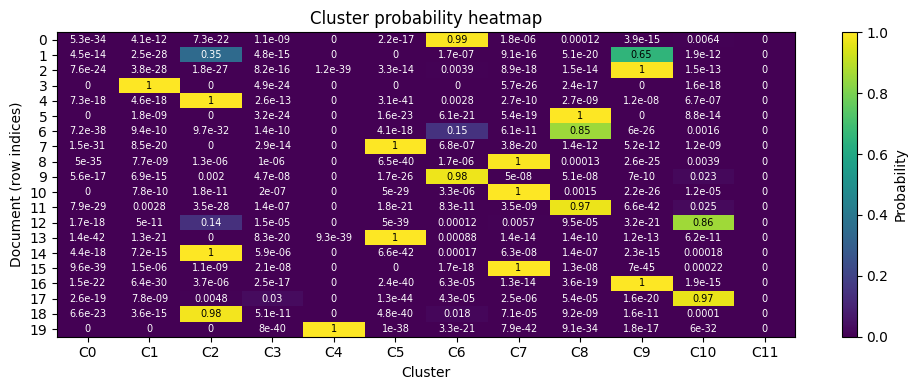

In [19]:
# build matrix
# rows are documents, cols are clusters
probs = np.vstack(publications_df["cluster_probs"].head(20).values)  # shape (n_docs, n_clusters)

fig, ax = plt.subplots(figsize=(10, max(4, probs.shape[0]*0.2)))
im = ax.imshow(probs, aspect="auto", cmap="viridis", interpolation="nearest")

# labels
ax.set_xlabel("Cluster")
ax.set_ylabel("Document (row indices)")
ax.set_title("Cluster probability heatmap")

# use document indices as y ticks
y_idx = np.arange(probs.shape[0])
ax.set_yticks(y_idx)

ax.set_xticks(np.arange(probs.shape[1]))
ax.set_xticklabels([f"C{c}" for c in range(probs.shape[1])])

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Probability")

# annotate values
for i in range(probs.shape[0]):
    for j in range(probs.shape[1]):
        val = probs[i, j]
        ax.text(j, i, f"{val:.2g}", ha="center", va="center",
                color="black" if val > 0.5*probs.max() else "white", fontsize=7)

plt.tight_layout()
plt.show()


## Check what the clusters contain

Check closest document to centroid

In [28]:
cluster_names = {}

for c in np.unique(publications_df["topic_cluster"]):
    idx = publications_df["topic_cluster"] == c
    cluster_embs = embeddings[idx] # On purpose not PCA
    
    centroid = cluster_embs.mean(axis=0)
    
    # find closest document to centroid
    sims = cluster_embs @ centroid
    best_doc = publications_df.loc[idx].iloc[np.argmax(sims)]["topic_text"]
    
    cluster_names[c] = best_doc[:40] # truncate for readability

cluster_names

{np.int64(0): 'Coronamentvm Veris Laureati Nouo eruditæ',
 np.int64(1): 'Srebrne Złotey Nałęczy Zadziergnienie, w',
 np.int64(2): 'Æcumenicum Ecclesiæ Vniversalis Conciliu',
 np.int64(3): 'Ivdex Ecclesiasticvs, Potestate Ligandi ',
 np.int64(4): 'Archiwum Macieja Sołtyka.',
 np.int64(5): 'Zguba Oyczyzny stacya /',
 np.int64(6): 'Chloris Cælica B. Salomæa Regina Haliciæ',
 np.int64(7): 'Rekreacya Przy Piątkv, Bez Smvtkv: z Nay',
 np.int64(8): 'Panegyricvs [...] Poloniæ Sveciæqve Prin',
 np.int64(9): 'Olor Wąsowicianvs In Cathedram Doctorale',
 np.int64(10): 'Gregorii Macri Szepsii Pannonis ... Lavr',
 np.int64(11): 'Dykcyonarz Powszechny Medyki, Chirurgii,'}

LLM-generated cluster names

In [ ]:
from ollama import ChatResponse, Client

cluster_samples = {}

for c in np.unique(publications_df["topic_cluster"]):
    idx = publications_df["topic_cluster"] == c
    cluster_embs = embeddings[idx] # On purpose not PCA
    cluster_texts = publications_df.loc[idx, "topic_text"].values

    centroid = cluster_embs.mean(axis=0)

    # similarity to centroid
    sims = cluster_embs @ centroid # since normalized embeddings

    top_idx = np.argsort(sims)[-10:] # top 100 most central docs
    cluster_samples[c] = set(cluster_texts[top_idx].tolist())

def build_prompt(texts, cluster_id):
    joined = "\n".join(f"- {t}" for t in texts)
    print(joined)

    return f"""
You are helping label a topic cluster.

Below are representative documents from one cluster:

{joined}

Task:
1. Give a short topic label (2-6 words)
2. Give a slightly longer description (1-2 sentences)

Return in JSON:
{{
  "label": "...",
  "description": "..."
}}

Do NOT write anything other than JSON.
Do NOT write fenced code blocks, only JSON.
Do NOT write multiple entries.
Write only ONE generalized, but not generic, entry with label and description, for all provided items.
In description, focus on domain (philosophy, alchemy, theology, astronomy, history, sermons, literature, medicine, geometry, architecture, ...), likely historical period if indicated, and language (old polish, latin, ...) used.
"""

def label_cluster_ollama(texts, cluster_id, model="llama3.2"):
    prompt = build_prompt(texts, cluster_id)
    client = Client(
        host='http://localhost:11434',
    )
    resp: ChatResponse = client.chat(
        model=model,
        messages=[
            {"role": "system", "content": "You are a precise topic labeling assistant."},
            {"role": "user", "content": prompt},
        ],
    )
    return resp.message.content

cluster_labels = {}

for c, texts in cluster_samples.items():
    print(f"\nLabeling cluster {c}")
    cluster_labels[c] = label_cluster_ollama(texts, c)
    print(cluster_labels[c])

cluster_labels


Labeling cluster 0
- Specvlvm Animorvm, Vere purpureo in Crystallinis fontibus Coronatvm, Virtuti & honori XVII. VV. DD. Primæ Laureæ Candidatorvm : Dvm In Alma Vniuersitate Cracouieinsi, Per [...] D. M. Martinvm Słowikowski, Philosophiæ Doctorem & Professorem [...], In florentißima Illustrium Hospitum corona, Artium & Philosophiæ Baccalaurei, Ritv Solenni Renvntiarentvr, Amoris & gratulationis ergo /
- Coronamentvm Veris Laureati Nouo eruditæ amœnitatis virore Efflorescens Virtuti, & honori VI. VV. DD. Primæ Lavreæ Candidatorvm : Dum in Alma vniuersitate Cracouiensi [...] Artium & Philosophiæ Baccalaurei [...] Renvntiarentvr [...] /
- Pleias Laureata Jn Virtute & honore VII. VV. DD. Primæ Laureæ Candidatorum, Refulgens Et dum In Alma Vniversitate Studij Generalis Cracoviensis Per [...] D. M. Ioannem Grymecki Philosopiæ Doctorem & Professorem [...] Jn Nobilissima Jllustrium Hospitum Corona Artivm & Philosopiæ Baccalavrei Ritu Solenni Renvntiarentvr [...] /
- Cornvcopiæ Lavreatvm, Vari

{np.int64(0): '{\n  "label": "Academic Degrees in Poland",\n  "description": "These documents represent academic degrees awarded to students at the University of Cracow during various periods, mostly in the late Middle Ages and early Renaissance, in fields such as philosophy, theology, and law"',
 np.int64(1): '{\n  "label": "Old Polish philosophical texts",\n  "description": "These documents represent Old Polish philosophical writings on various subjects, including alchemy, theology, and philosophy, written in the late 18th century, often using Latin influences and characteristics of Eastern European folk literature."',
 np.int64(2): '{\n  "label": "Letters to the Pope",\n  "description": "17th-18th century letters on various topics including theology, philosophy, and nobility from prominent individuals in Poland, written primarily in Latin with occasional Polish phrases"\n}',
 np.int64(3): '{\n  "label": "Polish Christian Theology",\n  "description": "Works from 16th-17th century Pol

## Compare with BERTopic

It mostly assigns outliers, which might be because the titles are rather heterogenous

In [23]:
from bertopic import BERTopic
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    min_samples=1,
    prediction_data=True,
)

topic_model = BERTopic(
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(
    publications_df["topic_text"].tolist(),
    embeddings
)

topic_info = topic_model.get_topic_info()
print(topic_info.head(20))

2026-06-09 20:46:49,011 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-09 20:47:06,581 - BERTopic - Dimensionality - Completed ✓
2026-06-09 20:47:06,582 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 20:47:08,476 - BERTopic - Cluster - Completed ✓
2026-06-09 20:47:08,481 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 20:47:08,659 - BERTopic - Representation - Completed ✓


    Topic  Count                                             Name  \
0      -1   1242                                   -1_in_de_ex_ad   
1       0    304                0_theologiæ_doctores_sacræ_doctor   
2       1    140                    1_iv_vladislai_sveciæ_poloniæ   
3       2    129                      2_pogrzebie_przy_na_kazanie   
4       3    115                    3_roku_dnia_pańskiego_walnego   
5       4    107                                 4_co_nouus_is_cu   
6       5     91                5_francisci_festa_applausus_inter   
7       6     90              6_dolore_ecclesia_joannis_capitanei   
8       7     77             7_qvæstio_natura_metaphysica_physicæ   
9       8     75                   8_regis_principis_poloniæ_regi   
10      9     75                   9_funere_cracovien_episcopi_mo   
11     10     71                     10_religii_wiary_christi_dla   
12     11     67                            11_primæ_vv_laureæ_dd   
13     12     65                  

# How do the topics change through time?

In [41]:
df = publications_df.copy()
df['date_start'] = pd.to_datetime(df['date_start'], errors='coerce')

# expand cluster_probs into columns
probs = np.vstack(df['cluster_probs'].apply(lambda x: np.array(x) if x is not None else np.zeros(K)))
cols = [f'cluster_{i}' for i in range(probs.shape[1])]
probs_df = pd.DataFrame(probs, columns=cols, index=df.index)

df = pd.concat([df, probs_df], axis=1)

# time period
df['year'] = df['date_start'].dt.year
df['decade'] = (df['year'] // 10) * 10

# aggregate sums per period
agg_year = df.groupby('year')[cols].sum().sort_index()
agg_decade = df.groupby('decade')[cols].sum().sort_index()
agg_decade_prop = agg_decade.div(agg_decade.sum(axis=1), axis=0).fillna(0)
agg_year_prop = agg_year.div(agg_year.sum(axis=1), axis=0).fillna(0)

Yearly cluster shares

<Figure size 1200x600 with 0 Axes>

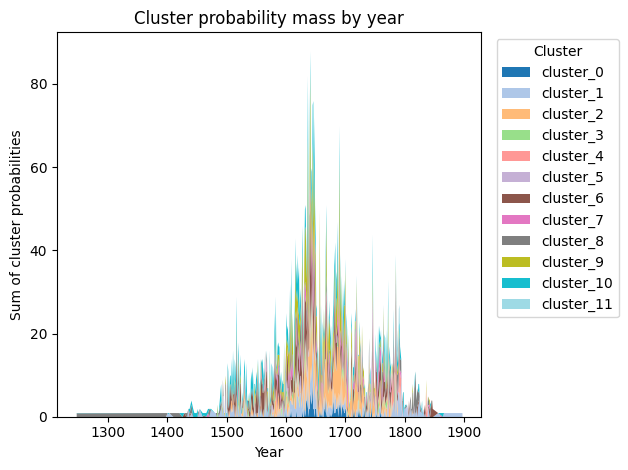

In [42]:
plt.figure(figsize=(12,6))
agg_year.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Year')
plt.ylabel('Sum of cluster probabilities')
plt.title('Cluster probability mass by year')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

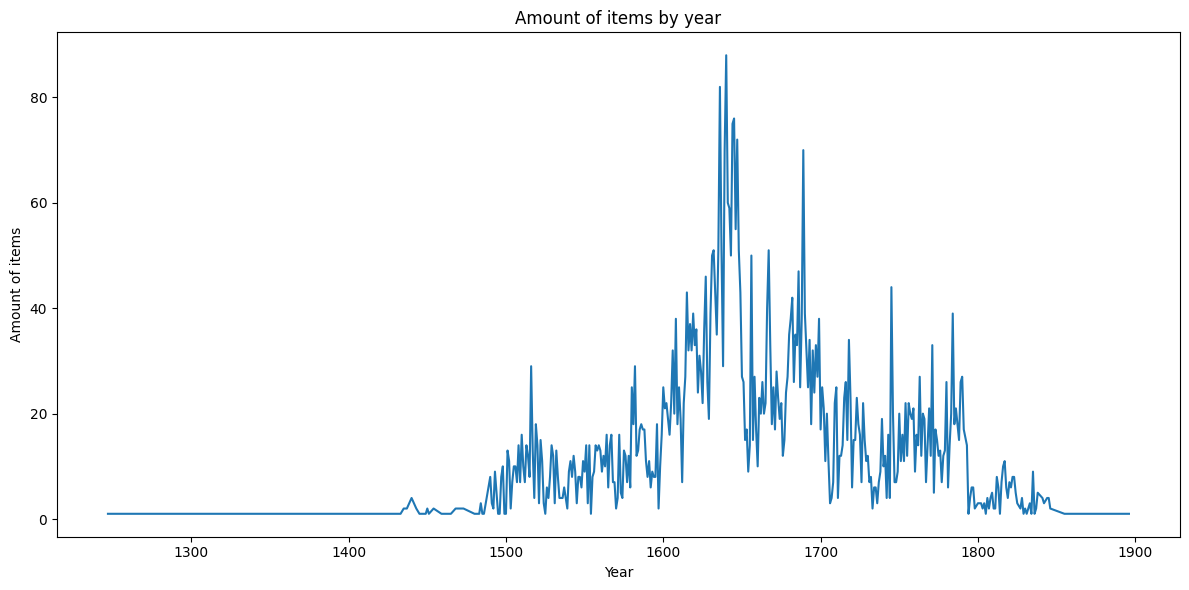

In [49]:
counts_year = df.groupby('year').size().sort_index()
plt.figure(figsize=(12,6))
counts_year.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Amount of items')
plt.title('Amount of items by year')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

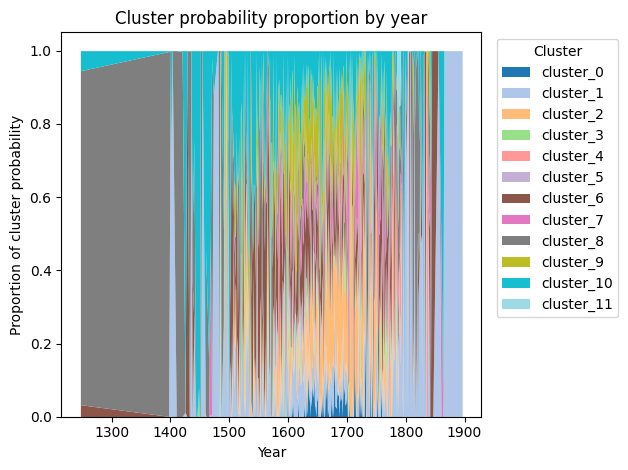

In [45]:
plt.figure(figsize=(12,6))
agg_year_prop.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Year')
plt.ylabel('Proportion of cluster probability')
plt.title('Cluster probability proportion by year')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

Cluster shares by decade

<Figure size 1200x600 with 0 Axes>

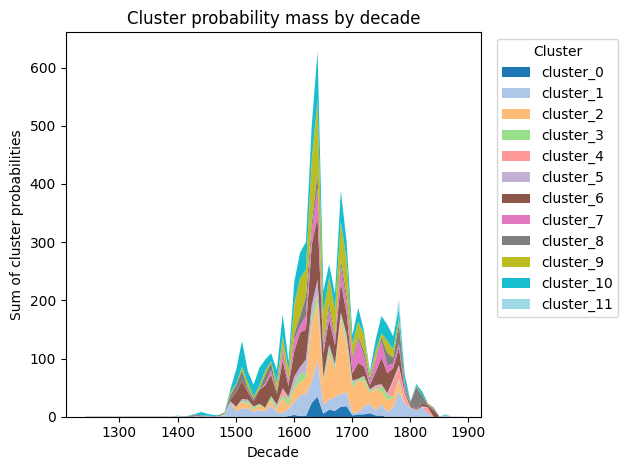

In [39]:
plt.figure(figsize=(12,6))
agg_decade.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Decade')
plt.ylabel('Sum of cluster probabilities')
plt.title('Cluster probability mass by decade')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

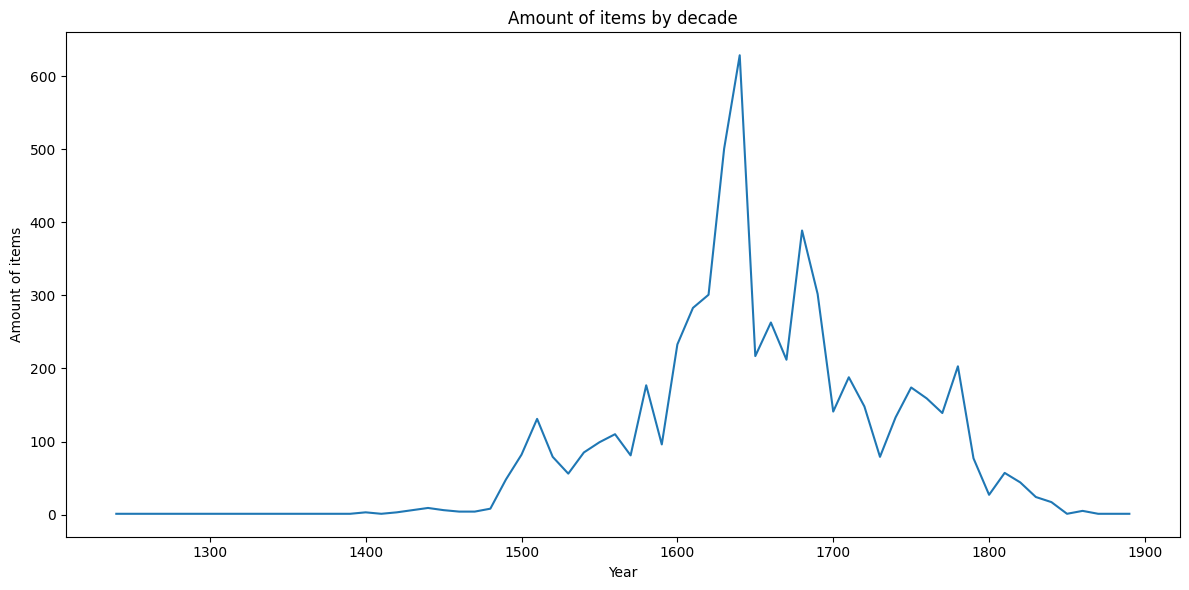

In [51]:
counts_decade = df.groupby('decade').size().sort_index()
plt.figure(figsize=(12,6))
counts_decade.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Amount of items')
plt.title('Amount of items by decade')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

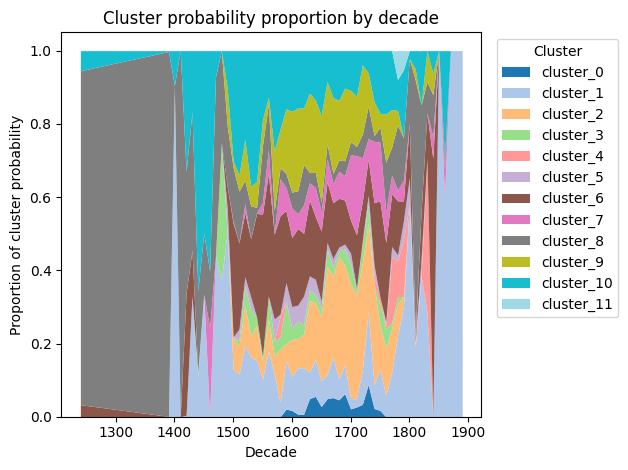

In [44]:
plt.figure(figsize=(12,6))
agg_decade_prop.plot.area(colormap='tab20', linewidth=0)
plt.xlabel('Decade')
plt.ylabel('Proportion of cluster probability')
plt.title('Cluster probability proportion by decade')
plt.legend(title='Cluster', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

# Do topics of earlier publications influence topics of future publications of the same researcher?